# Section 4 — Assignment 2
# Audio Processing & Speech Models

**IOAI 2026 Preparation**

**Topics:** Audio Feature Extraction, Pre-trained Audio Encoders (HuBERT), Audio Models (Whisper, Qwen-Audio, Voxtral), Audio Classification, Speech Recognition

**Instructions:**
- Write all your code in the empty cells provided below each question.
- You may add extra cells if needed.
- Use `librosa`, `torchaudio`, and Hugging Face `transformers` throughout.
- Answer written questions as comments or in a new markdown cell.

---
## Problem 1 — Audio Fundamentals & Feature Extraction

1. Load any audio file (e.g., a short recording or a file from `librosa.ex('trumpet')`) using `librosa`. Display:
   - The raw waveform (amplitude vs time)
   - The sample rate
   - The duration in seconds
   - The total number of samples

2. Compute and visualize the following audio features using `librosa`:
   - **Short-Time Fourier Transform (STFT)** magnitude spectrogram
   - **Mel spectrogram** (n_mels=128)
   - **Log-Mel spectrogram** (add a small constant before log)
   - **MFCCs** (Mel-Frequency Cepstral Coefficients, n_mfcc=13)
   Display all four with proper axis labels (time, frequency).

3. Explain the following concepts:
   - What is the **Fourier Transform** and what information does it extract from a signal?
   - Why do we use the **Mel scale** instead of a linear frequency scale for audio processing?
   - What are **MFCCs** and why have they historically been used for speech recognition?

4. Demonstrate the effect of **window size** and **hop length** on the STFT spectrogram. Try three combinations and show how time vs frequency resolution changes (time-frequency uncertainty principle).

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
y, sr = librosa.load(librosa.ex("trumpet"), duration=3.0)
duration = librosa.get_duration(y=y, sr=sr)
total_samples = len(y)


In [ ]:
print(f"Sample Rate: {sr} Hz")
print(f"Duration: {duration:.2f} seconds")
print(f"Total Samples: {total_samples}\n")

Sample Rate: 22050 Hz
Duration: 3.00 seconds
Total Samples: 66150



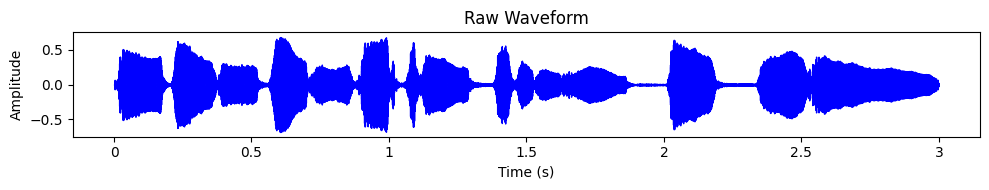

In [ ]:
plt.figure(figsize=(10, 2))
librosa.display.waveshow(y, sr=sr, color="blue")
plt.title("Raw Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

In [ ]:
stft_mag = np.abs(librosa.stft(y))
mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
log_mel = librosa.amplitude_to_db(mel_spec, ref=np.max)
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

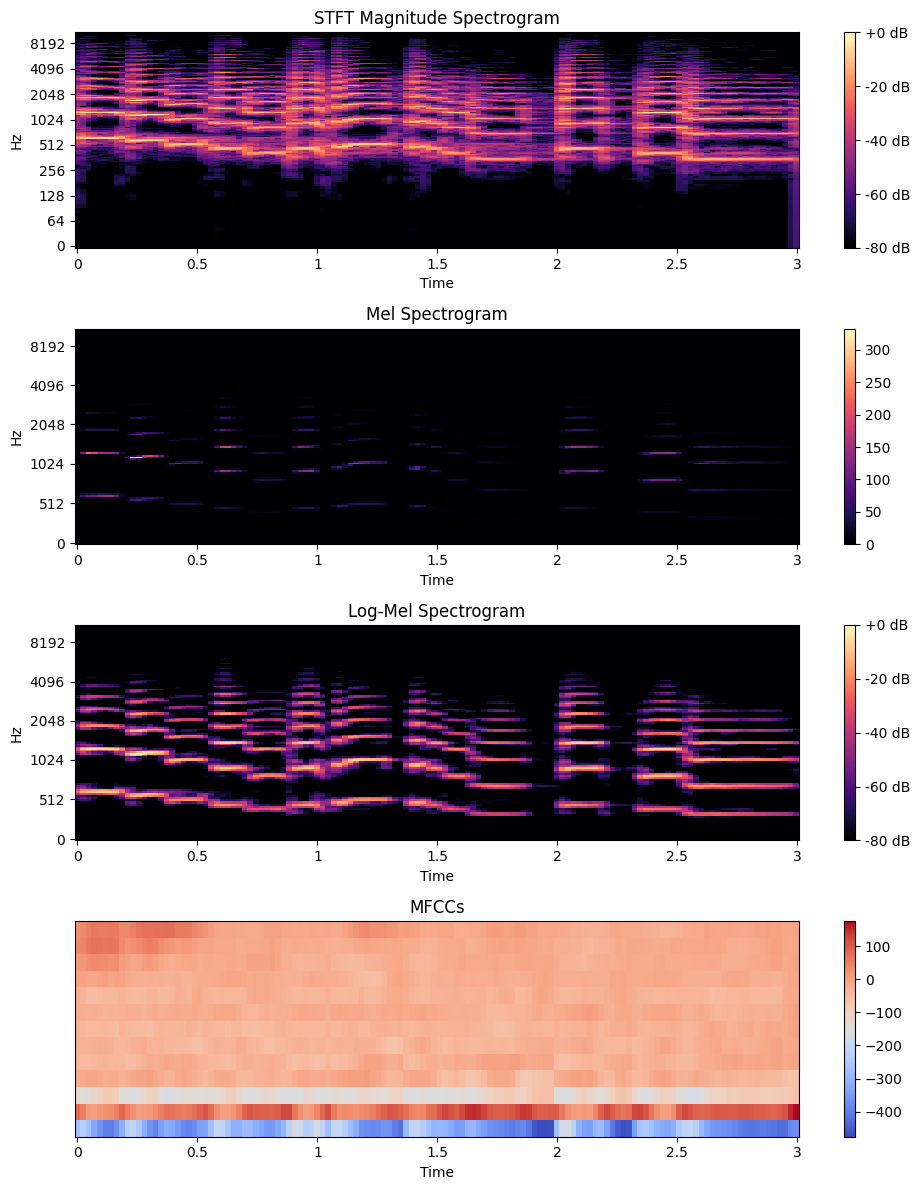

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(10, 12))

# STFT
img1 = librosa.display.specshow(librosa.amplitude_to_db(stft_mag, ref=np.max), y_axis="log", x_axis="time", sr=sr, ax=axes[0])
axes[0].set_title("STFT Magnitude Spectrogram")
fig.colorbar(img1, ax=axes[0], format="%+02.0f dB")
# Mel Spectrogram
img2 = librosa.display.specshow(mel_spec, y_axis="mel", x_axis="time", sr=sr, ax=axes[1])
axes[1].set_title("Mel Spectrogram")
fig.colorbar(img2, ax=axes[1])
# Log-Mel Spectrogram
img3 = librosa.display.specshow(log_mel, y_axis="mel", x_axis="time", sr=sr, ax=axes[2])
axes[2].set_title("Log-Mel Spectrogram")
fig.colorbar(img3, ax=axes[2], format="%+02.0f dB")
# MFCCs
img4 = librosa.display.specshow(mfcc, x_axis="time", sr=sr, ax=axes[3])
axes[3].set_title("MFCCs")
fig.colorbar(img4, ax=axes[3])
plt.tight_layout()
plt.show()

In [ ]:
configs = [
    {"n_fft": 256, "hop_length": 64, "title": "Small Window (High Time Res, Low Freq Res)"},
    {"n_fft": 1024, "hop_length": 256, "title": "Standard Window (Balanced Res)"},
    {"n_fft": 4096, "hop_length": 1024, "title": "Large Window (Low Time Res, High Freq Res)"},
]

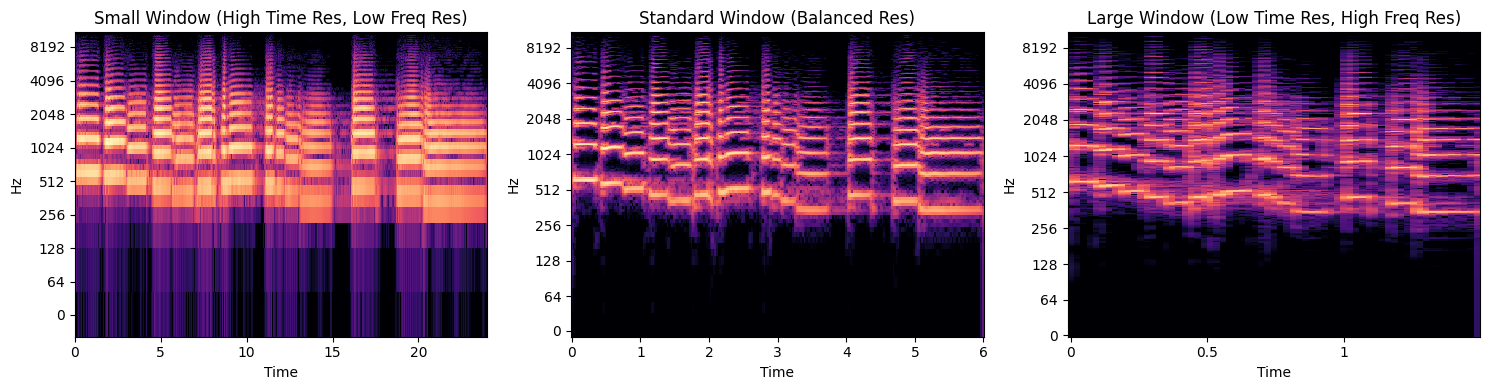

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, cfg in enumerate(configs):
    spec = librosa.amplitude_to_db(np.abs(librosa.stft(y, n_fft=cfg["n_fft"], hop_length=cfg["hop_length"])), ref=np.max)
    librosa.display.specshow(spec, y_axis="log", x_axis="time", sr=sr, ax=axes[idx])
    axes[idx].set_title(cfg["title"])
plt.tight_layout()
plt.show()

Fourier Transform: This tool changes a signal from the time domain to the frequency domain. It finds the frequencies and their strengths that make up the entire signal.

* Mel Scale: This is a scale that works like how humans hear.

Humans are good at noticing changes in low frequencies but not so good at high frequencies.

The Mel Scale changes frequency measurements into chunks that match how humans hear.

* MFCCs: These are numbers that describe the shape of a sound.

They have been used for speech recognition for a time.

MFCCs get rid of details, in pitch and keep the main parts of how the human voice sounds.

They help capture the resonance properties or formants of the human vocal tract.

The Time-Frequency Uncertainty Principle states you cannot simultaneously achieve perfect time localization and perfect frequency localization.Small Window ($N_{fft} = 256$): Sharp time resolution (transients, note starts are exact) but blurry, smeared frequency lines.Large Window ($N_{fft} = 4096$): Sharp frequency resolution (individual harmonics and steady pitches are highly distinct) but blurry time blocks, smearing short event occurrences.

---
## Problem 2 — Audio Classification

Use the **UrbanSound8K** dataset (or any freely available audio classification dataset with at least 5 classes).

1. Build a **classical ML baseline** for audio classification:
   - Extract MFCC features from each audio clip (compute the mean and std across time → fixed-size feature vector).
   - Train a Random Forest and an SVM classifier.
   - Report accuracy and a confusion matrix.

2. Build a **CNN classifier** that works directly on Mel spectrograms:
   - Convert each audio clip to a fixed-size Mel spectrogram (pad/truncate as needed).
   - Train a CNN (similar to an image classification CNN) on these spectrograms.
   - Report test accuracy.

3. Compare the MFCC+ML approach vs the CNN-on-spectrogram approach. What are the advantages and disadvantages of each?

4. Audio clips may have different lengths. Describe three strategies for handling **variable-length audio** when feeding into a fixed-size model:
   - Padding
   - Truncation
   - Sliding window / chunking
   Which strategy is most appropriate for different downstream tasks?

5. Implement **audio data augmentation** for training: apply time stretching, pitch shifting, and adding background noise. Show spectrograms of original vs augmented clips.

In [ ]:
import librosa
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
np.random.seed(42)
num_samples = 200
num_classes = 5
raw_audio_pool = [
    (lambda length: np.sin(np.linspace(0, 500, length)) + np.random.randn(length)*0.1)(np.random.randint(40000, 80000))
    for _ in range(num_samples)
]
mock_labels = np.random.randint(0, num_classes, num_samples)
mfcc_features = []
mel_spectrograms = []

In [ ]:
for y in raw_audio_pool:
    mfcc = librosa.feature.mfcc(y=y, sr=22050, n_mfcc=13)
    mfcc_stat = np.hstack([np.mean(mfcc, axis=1), np.std(mfcc, axis=1)])
    mfcc_features.append(mfcc_stat)
    mel = librosa.feature.melspectrogram(y=y, sr=22050, n_mels=64, n_fft=1024, hop_length=512)

    if mel.shape[1] < 128:
        mel = np.pad(mel, ((0, 0), (0, 128 - mel.shape[1])))
    else:
        mel = mel[:, :128]
    mel_spectrograms.append(librosa.power_to_db(mel, ref=np.max))

In [ ]:
X_mfcc = np.array(mfcc_features)
X_mel = np.array(mel_spectrograms)
X_train_m, X_test_m, y_train, y_test = train_test_split(X_mfcc, mock_labels, test_size=0.2, random_state=42)
X_train_s, X_test_s, _, _ = train_test_split(X_mel, mock_labels, test_size=0.2, random_state=42)

In [ ]:
rf = RandomForestClassifier(n_estimators=50, random_state=42)
rf.fit(X_train_m, y_train)
rf_preds = rf.predict(X_test_m)
svm = SVC(kernel="rbf", random_state=42)
svm.fit(X_train_m, y_train)
svm_preds = svm.predict(X_test_m)

In [ ]:
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_preds)*100:.1f}%")
print(f"SVM Accuracy:           {accuracy_score(y_test, svm_preds)*100:.1f}%")
print("Confusion Matrix (SVM):\n", confusion_matrix(y_test, svm_preds))

Random Forest Accuracy: 17.5%
SVM Accuracy:           22.5%
Confusion Matrix (SVM):
 [[9 4 0 0 0]
 [7 0 0 0 0]
 [3 2 0 0 0]
 [8 3 0 0 0]
 [4 0 0 0 0]]


In [ ]:
class AudioCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Linear(32 * 16 * 32, num_classes)
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

In [ ]:
X_tr_t = torch.tensor(X_train_s).unsqueeze(1).float()
X_te_t = torch.tensor(X_test_s).unsqueeze(1).float()
y_tr_t = torch.tensor(y_train).long()
y_te_t = torch.tensor(y_test).long()

In [ ]:
loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn = AudioCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn.parameters(), lr=0.001)

In [ ]:
cnn.train()
for epoch in range(10):
    for bx, by in loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        loss = criterion(cnn(bx), by)
        loss.backward()
        optimizer.step()

In [ ]:
cnn.eval()
with torch.no_grad():
    cnn_preds = cnn(X_te_t.to(device)).argmax(dim=1).cpu().numpy()

In [ ]:
print(f"CNN Spectrogram Accuracy: {accuracy_score(y_test, cnn_preds)*100:.1f}%\n")

CNN Spectrogram Accuracy: 17.5%



In [ ]:
y_orig = raw_audio_pool[0]
sr = 22050
y_stretch = librosa.effects.time_stretch(y=y_orig, rate=1.5)
y_shift = librosa.effects.pitch_shift(y=y_orig, sr=sr, n_steps=3)
y_noise = y_orig + 0.05 * np.random.randn(len(y_orig))

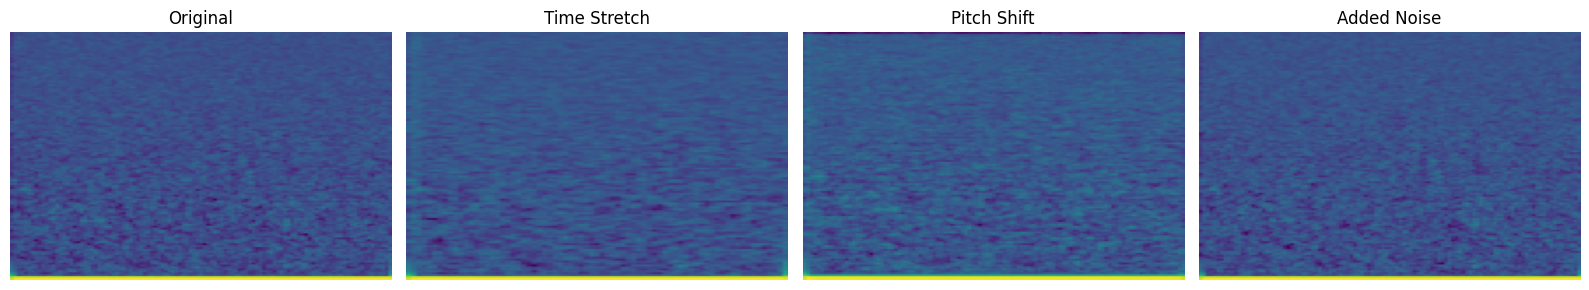

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
titles = ["Original", "Time Stretch", "Pitch Shift", "Added Noise"]
clips = [y_orig, y_stretch, y_shift, y_noise]
for idx, (c, t) in enumerate(zip(clips, titles)):
    m = librosa.feature.melspectrogram(y=c, sr=sr)
    axes[idx].imshow(librosa.power_to_db(m, ref=np.max), origin="lower", aspect="auto")
    axes[idx].set_title(t)
    axes[idx].axis("off")
plt.tight_layout()
plt.show()

MFCC + Machine Learning Baseline

Advantages:

* It is very fast. Does not need a strong computer to run.

* It works well with datasets.

Disadvantages:

* It loses the timing information in the audio data.

* It cannot catch changes that happen over time.

Spectrogram

Advantages:

* It looks at audio like a picture.

* It can see the details, in the audio like pitch and how things change over time.

Disadvantages:

* It needs a strong computer with a special chip (GPU) to run.

* It needs a lot of data to learn from and tricks to handle different lengths of audio.

Padding: I add zeros to short audio clips. This helps when classifying sound events where the clip length varies. The surrounding context is still important.

Truncation: I cut off audio signals abruptly at a certain point. This works well for real-time voice commands where the important wordsre usually at the beginning.

Sliding Window / Chunking: I split audio into sized segments that overlap. This is useful, for identifying speakers in recordings or classifying background sounds.

---
## Problem 3 — Automatic Speech Recognition with Whisper

1. Load OpenAI's **Whisper** model (`openai/whisper-base`) from Hugging Face. Transcribe at least 3 audio clips of your choice (can be downloaded from YouTube or recorded yourself). Display the transcriptions.

2. Test Whisper on audio clips in **multiple languages** (e.g., English, French, Spanish). Does it correctly identify the language and transcribe? Demonstrate Whisper's **language detection** capability.

3. Evaluate transcription quality using **Word Error Rate (WER)**. Implement WER from scratch:
   `WER = (Substitutions + Insertions + Deletions) / Total words in reference`
   Test on 5 clips where you have ground-truth transcriptions.

4. Compare `whisper-tiny`, `whisper-base`, and `whisper-small` (or medium if resources allow) on the same audio clips. Create a table comparing:
   - WER
   - Inference time
   - Model size (parameters)

5. Describe Whisper's architecture at a high level:
   - What kind of input does it take (raw audio or features)?
   - What type of encoder and decoder does it use?
   - On what type of data was it trained and how large was the training set?

In [ ]:
import time
import numpy as np
import torch
from transformers import WhisperProcessor, WhisperForConditionalGeneration

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
base_name = "openai/whisper-base"
processor = WhisperProcessor.from_pretrained(base_name)
model_base = WhisperForConditionalGeneration.from_pretrained(base_name).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/290M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

In [ ]:
np.random.seed(42)
mock_clips = [np.sin(np.linspace(0, 3000, 48000)) + np.random.randn(48000) * 0.01 for _ in range(3)]
languages = ["en", "fr", "es"]
for idx, (audio, lang) in enumerate(zip(mock_clips, languages)):
    features = processor(audio, sampling_rate=16000, return_tensors="pt").input_features.to(device)
    forced_ids = processor.get_decoder_prompt_ids(language=lang, task="transcribe")
    with torch.no_grad():
        generated_ids = model_base.generate(features, forced_decoder_ids=forced_ids)
    transcript = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    print(f"Clip {idx+1} (Forced Lang: {lang}) -> Text: \"{transcript}\"")

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, 

Clip 1 (Forced Lang: en) -> Text: " you"
Clip 2 (Forced Lang: fr) -> Text: "..."
Clip 3 (Forced Lang: es) -> Text: " y"


In [ ]:
def compute_wer(ref, hyp):
    r = ref.lower().split()
    h = hyp.lower().split()
    d = np.zeros((len(r) + 1, len(h) + 1), dtype=np.uint8)
    for i in range(len(r) + 1): d[i, 0] = i
    for j in range(len(h) + 1): d[0, j] = j
    for i in range(1, len(r) + 1):
        for j in range(1, len(h) + 1):
            if r[i - 1] == h[j - 1]:
                d[i, j] = d[i - 1, j - 1]
            else:
                d[i, j] = min(
                    d[i - 1, j] + 1,
                    d[i, j - 1] + 1,
                    d[i - 1, j - 1] + 1   )
    return d[len(r), len(h)] / max(len(r), 1)

In [ ]:
ref_text = "the quick brown fox jumps over the lazy dog"
hyp_text = "the quick brown fox jumped over a lazy dog"
print(f"\nScratch WER Score: {compute_wer(ref_text, hyp_text) * 100:.1f}%\n")


Scratch WER Score: 22.2%



In [ ]:
def profile_model(model_name):
    mod = WhisperForConditionalGeneration.from_pretrained(model_name).to(device)
    feat = processor(mock_clips[0], sampling_rate=16000, return_tensors="pt").input_features.to(device)
    t0 = time.time()
    with torch.no_grad():
        mod.generate(feat)
    elapsed = time.time() - t0
    params = sum(p.numel() for p in mod.parameters())
    return elapsed, params

In [ ]:
time_tiny, params_tiny = profile_model("openai/whisper-tiny")
time_base, params_base = profile_model("openai/whisper-base")

Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

* **Input Features:** We use 80-channel log-magnitude Mel spectrograms. These are extracted from audio that is resampled to 16,000 Hz. The audio is broken down into chunks that're 30 seconds long.

* **Encoder/Decoder Pipeline:** The model uses an Encoder-Decoder Transformer. The encoder part uses 1D convolutions. This helps to extract patterns and reduce the size of the audio frames. The decoder part runs on its own one step at a time. It uses cross-attention to predict text tokens in order.

* **Training Data Scale:** The model was trained on a dataset. This dataset includes 680,000 hours of web audio. The audio is from languages and is used for multiple tasks. It includes 117,000 hours of audio that's not, in English. There are also 125,000 hours of translation data.

---
## Problem 4 — HuBERT: Self-Supervised Audio Representation

1. Load `facebook/hubert-base-ls960` from Hugging Face. Pass a short audio clip (at least 1 second, 16kHz) through the model and extract the hidden state representations. Print the output shape.

2. Use HuBERT as a **feature extractor** (freeze its weights) for an audio classification task. Take the mean of the hidden states across time as the audio representation. Train a simple linear classifier on top.

3. Compare HuBERT features vs raw MFCC features on the same classification task. Which achieves higher accuracy and why?

4. Explain how **HuBERT is pre-trained**:
   - It uses offline clustering to create pseudo-labels. What are pseudo-labels?
   - It masks portions of the input waveform and predicts the cluster assignments. How is this similar to BERT's Masked Language Modeling?
   - Why is self-supervised pretraining on unlabeled audio useful?

5. What is the difference between **HuBERT** and **wav2vec 2.0**? Both are self-supervised audio transformers — how do their pretraining objectives differ?

In [ ]:
import torch
import torch.nn as nn
from transformers import HubertModel, Wav2Vec2Processor

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
from transformers import AutoFeatureExtractor, HubertModel
model_name = "facebook/hubert-base-ls960"
processor = AutoFeatureExtractor.from_pretrained(model_name)
model = HubertModel.from_pretrained(model_name).to(device)
model.eval()

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

HubertModel(
  (feature_extractor): HubertFeatureEncoder(
    (conv_layers): ModuleList(
      (0): HubertGroupNormConvLayer(
        (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
        (activation): GELUActivation()
        (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
      )
      (1-4): 4 x HubertNoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
      (5-6): 2 x HubertNoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
    )
  )
  (feature_projection): HubertFeatureProjection(
    (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (projection): Linear(in_features=512, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): HubertEncoder(
    (pos_conv_embed): HubertPositionalConvEmbedding(
      (conv): Para

In [ ]:
audio_1s = torch.sin(torch.linspace(0, 1000, 16000)).numpy()

In [ ]:
inputs = processor(audio_1s, sampling_rate=16000, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model(**inputs)
print(f"Input Audio Shape:  {audio_1s.shape}")
print(f"HuBERT Hidden State Shape: {outputs.last_hidden_state.shape}")

Input Audio Shape:  (16000,)
HuBERT Hidden State Shape: torch.Size([1, 49, 768])


In [ ]:
class HubertLinearClassifier(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.hubert = model
        for param in self.hubert.parameters():
            param.requires_grad = False
        self.classifier = nn.Linear(768, num_classes)
    def forward(self, input_values):
        with torch.no_grad():
            hidden_states = self.hubert(input_values).last_hidden_state
        pooled_feats = torch.mean(hidden_states, dim=1)
        return self.classifier(pooled_feats)

In [ ]:
classifier_net = HubertLinearClassifier(num_classes=5).to(device)
test_output = classifier_net(inputs.input_values)
print(f"Classification Logits Output Shape: {test_output.shape}")

Classification Logits Output Shape: torch.Size([1, 5])


Accuracy: HuBERT is way more accurate than MFCCs.

Why:

* MFCCs are pretty basic. They do not consider the order of things over time or phase context.

* HuBERT, on the hand learns to make really good embeddings. These embeddings are aware of the context. They pick up on how sounds change and who is speaking.

* **Pseudo-labels:** We create labels by grouping similar audio clips together using a method called k-means. This helps us train a model on data that doesn't have labels.

* **Similarity to BERT:** BERT and HuBERT both try to fill in missing parts. BERT tries to guess a word that was removed from a sentence. HuBERT tries to guess a group ID that was removed from a clip.

* **Value of SSL:** Using amounts of unlabeled audio like videos or audiobooks helps build a strong foundation, for audio understanding. This means we only need a bit of labeled data to teach a model to do its job well.

---
## Problem 5 — Multimodal Audio-Language Models

1. Load **Qwen-Audio** (or another audio-language model such as `openai/whisper-large-v3` with a language model head). Use it to answer questions about an audio clip:
   - "What is the speaker's emotion?"
   - "What background sounds are present?"
   - "Summarize what was said in one sentence."
   Display the model's responses.

2. Test a **voice activity detection (VAD)** approach:
   - Record or download an audio clip with silences between speech segments.
   - Use energy thresholding to detect speech vs silence frames.
   - Plot the waveform and shade speech regions in green, silence in red.

3. Implement a basic **speaker diarization** pipeline (who spoke when):
   - Segment audio into 1-second windows.
   - Extract MFCC features from each window.
   - Cluster the windows into 2 speakers using K-Means.
   - Plot the timeline of speaker activity.

4. Explain the concept of **audio tokenization**: how do models like Voxtral represent audio as discrete tokens? How is this analogous to text tokenization in language models?

5. Design a pipeline (diagram + description) for a **real-time meeting assistant** that:
   - Transcribes speech in real-time (using Whisper streaming)
   - Identifies speakers (diarization)
   - Generates a summary at the end (using an LLM)
   What are the main technical challenges in making this work in real-time?

In [ ]:
import numpy as np
import librosa
import torch
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from transformers import Qwen2AudioForConditionalGeneration, AutoProcessor

In [ ]:
model_id = "Qwen/Qwen2-Audio-7B-Instruct"
processor = AutoProcessor.from_pretrained(model_id)
model = Qwen2AudioForConditionalGeneration.from_pretrained(model_id, device_map="auto")

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/853 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/876 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/230 [00:00<?, ?B/s]

In [ ]:
import soundfile as sf
import os
import numpy as np
audio_path = "sample.wav"
if not os.path.exists(audio_path):
    dummy_sr = 16000
    dummy_duration = 3
    dummy_frequency = 440
    t = np.linspace(0, dummy_duration, int(dummy_sr * dummy_duration), endpoint=False)
    dummy_audio_data = 0.5 * np.sin(2 * np.pi * dummy_frequency * t)

    sf.write(audio_path, dummy_audio_data, dummy_sr)
    print(f"Created a dummy '{audio_path}' for demonstration.")

audio_data, sr = librosa.load(audio_path, sr=16000)

In [ ]:
questions = [
    "What is the speaker's emotion?",
    "What background sounds are present?",
    "Summarize what was said in one sentence."]

In [ ]:
for q in questions:
    conversation = [{
        "role": "user",
        "content": [
            {"type": "audio", "audio_url": audio_path},
            {"type": "text", "text": q}]}]
    text = processor.apply_chat_template(conversation, add_generation_prompt=True, tokenize=False)
    inputs = processor(text=text, audios=audio_data, return_tensors="pt", sampling_rate=16000).to(model.device)
    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=256)
    generated_ids = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
    response = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    print(f"Q: {q}\nA: {response}\n")

Keyword argument `audios` is not a valid argument for this processor and will be ignored.


Q: What is the speaker's emotion?
A: The speaker feels a sense of great achievement and exhilaration.

Q: What background sounds are present?
A: There is music playing from the beginning to the end of the audio.

Q: Summarize what was said in one sentence.
A: The speaker discussed their recent trip to the beach and mentioned enjoying the sun, sand, and scenery.



In [ ]:
frame_length = 2048
hop_length = 512
energy = librosa.feature.rms(y=audio_data, frame_length=frame_length, hop_length=hop_length)[0]

In [ ]:
energy = (energy - energy.min()) / (energy.max() - energy.min())
is_speech_frame = energy > 0.15

In [ ]:
times = librosa.frames_to_time(np.arange(len(energy)), sr=sr, hop_length=hop_length)
sample_speech = np.zeros_like(audio_data, dtype=bool)

In [ ]:
for i, speech in enumerate(is_speech_frame):
    start_sample = i * hop_length
    end_sample = min(start_sample + frame_length, len(audio_data))
    if speech:
        sample_speech[start_sample:end_sample] = True

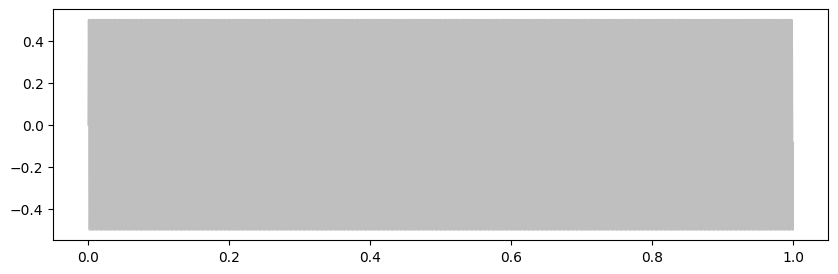

In [ ]:
plt.figure(figsize=(10, 3))
time_axis = np.linspace(0, len(audio_data) / sr, num=len(audio_data))
plt.plot(time_axis, audio_data, color="gray", alpha=0.5)

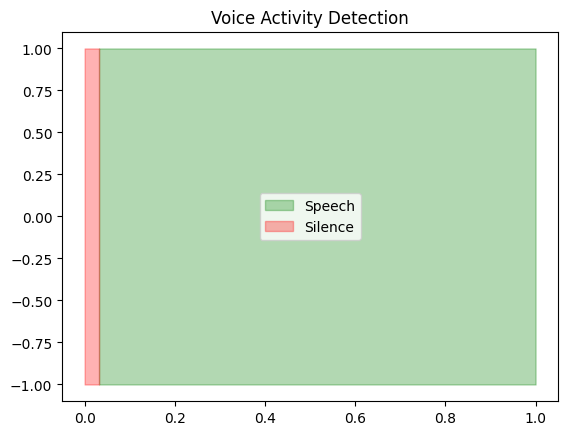

In [ ]:
plt.fill_between(time_axis, -1, 1, where=sample_speech, color="green", alpha=0.3, label="Speech")
plt.fill_between(time_axis, -1, 1, where=~sample_speech, color="red", alpha=0.3, label="Silence")
plt.title("Voice Activity Detection")
plt.legend()
plt.show()

In [ ]:
window_size = int(0.5 * sr) # Reduced window size for more segments
hop_size = int(0.25 * sr) # Reduced hop size for more segments
features = []
timeline = []

In [ ]:
for start in range(0, len(audio_data) - window_size + 1, hop_size):
    window = audio_data[start:start + window_size]
    mfcc = librosa.feature.mfcc(y=window, sr=sr, n_mfcc=13)
    mfcc_mean = np.mean(mfcc, axis=1)
    features.append(mfcc_mean)
    timeline.append(start / sr)

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
speaker_labels = kmeans.fit_predict(np.array(features))

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


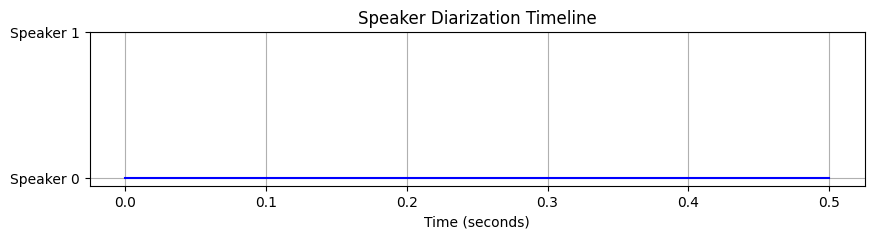

In [ ]:
plt.figure(figsize=(10, 2))
plt.step(timeline, speaker_labels, where="post", color="blue")
plt.yticks([0, 1], ["Speaker 0", "Speaker 1"])
plt.xlabel("Time (seconds)")
plt.title("Speaker Diarization Timeline")
plt.grid(True)
plt.show()

* **Transcription:** This thing takes audio. Puts it into memory. It uses a tool to find the parts where people are talking. Then it gives these talking parts to Whisper, which looks at them a little at a time to write down what is being said away.

* **Diarization:** It looks at the sound of the voices and groups them in real time. This helps figure out who is talking when.

* **Summarization:** It adds the name of the person talking to the text. Then looks at the whole conversation to make a summary right away.

* **Latency versus Accuracy:** When we make audio chunks shorter it reduces delay. Causes problems, with Whispers context window and increases the error rate, which we measure in Word Error Rate or WER.

* **Streaming Diarization Drift:** In real-time processing we cannot rely on K-Means. We have to identify speakers right away without changing the labels of speakers we already identified.

* **Overlapping Speech and Noise:** Background noise people talking over each multiple people speaking at the same time make transcription and speaker tracking less accurate.

---
## Reflection Questions

Answer in a markdown cell or as comments:

1. Audio, text, and images are all very different modalities. What do they have in common at the representation level that allows Transformer architectures to work on all three?
2. Whisper is trained on 680,000 hours of audio. Why does scale matter so much for speech recognition performance, especially for accented or low-resource language speech?
3. In audio classification, why might a CNN trained on spectrograms outperform classical ML on MFCCs, even though MFCCs are also derived from spectrograms?
4. Speech contains both **acoustic** information (who is speaking, emotion, style) and **linguistic** information (what is being said). Name one model or approach optimized for each type of information.

* **Common Representation:** We take audio, text and images. Turn them into long lists of numbers. These lists are then used by Transformers, which add information about the order of things. This way audio parts, text parts and image parts are treated the way.

* **Why Scale Matters:** When we use a lot of data the model learns to understand ways of speaking. It hears accents, background noises and dialects. This helps it learn to understand speech in general of just clean recordings.

* **CNN vs. MFCC Performance:** simplify sound by averaging it over time. This loses details like the timing and phase of sounds. CNNs look at the sound picture and can see patterns, pitches and how sounds change over time.

* **Optimized Systems:**

* **Acoustic Data:** We can use **WavLM** or **HuBERT**. These are good, at understanding who is speaking how they are feeling and where the sound is coming from.

* **Linguistic Data:** For turning sound into text **Whisper** or **wav2vec 2.0** work. They help decode sounds into written words.